# ChurnScope AI — Forecast → Classify → Explain → Act

**Academic project notebook · Subscription-based learning platform**

This notebook is the reproducible ML and evidence pipeline behind the demo. The prediction date is after week 32; the target represents cancellation in the following four-week window. Every feature uses records available through week 32 only.

## A — Problem definition

We want to segment learners by behavior, estimate individual churn probability, forecast future usage, explain the classifier output, and select a suitable retention action.

- **Clustering ≠ classification:** clustering groups similar activity profiles without churn labels; classification estimates an individual cancellation probability.
- **Forecasting** estimates future weekly usage from the observed timeline.
- **SHAP** attributes a fitted classifier’s output to features; it does not show causal effects.
- **LLM agent** reasons over verified model outputs and recorded preferences to suggest an allowed intervention. It does not create scientific evidence.

Cancellation outcomes overlap across behavior patterns. Demographics and preferences do not determine the label.

In [1]:
from pathlib import Path
import sys, json, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display, Markdown
ROOT=Path.cwd()
if not (ROOT/'scripts').exists(): ROOT=Path.cwd().parent
sys.path.insert(0,str(ROOT)); sys.path.insert(0,str(ROOT/'scripts'))
sns.set_theme(style='whitegrid',palette='deep')
pd.set_option('display.max_columns',30)
print('Project root:',ROOT)

Project root: C:\Users\LAPSHOP\Documents\Time Forecasting project


## B — Data exploration

Generate 300 reproducible learner profiles and 32 weeks of activity each. The six patterns represent stable, gradually declining, sudden decline, irregular, dormant, and recovering usage. The fixed random seed is 42.

In [2]:
from scripts.generate_data import generate
history,profiles=generate()
print('Weekly history:',history.shape,'| Profiles:',profiles.shape)
display(history.head()); display(profiles.head())
print('Missing weekly values:',int(history.isna().sum().sum()))
display(history.describe().round(2).T)
display(history.groupby('customer_id').cancelled.max().value_counts().rename(index={0:'did not cancel',1:'cancelled'}).to_frame('customers'))

Weekly history: (9600, 12) | Profiles: (300, 7)


,customer_id,week,weekly_sessions,active_days,usage_minutes,completed_lessons,completed_labs,searches,support_requests,days_since_last_activity,subscription_age_weeks,cancelled
0,C001,1,12,7,290.7,5,2,6,0,16,59,0
1,C001,2,13,7,433.7,5,3,7,0,6,12,0
2,C001,3,14,6,533.9,3,1,7,0,7,65,0
3,C001,4,16,6,358.1,10,3,1,0,2,41,0
4,C001,5,23,7,272.5,8,0,6,0,8,53,0


,customer_id,age_group,favorite_topic,preferred_content_type,preferred_feature,preferred_study_time,historical_engagement_level
0,C001,25–34,Deep Learning,Videos,Projects,Evening,High
1,C002,45+,Deep Learning,Projects,Practice Problems,Weekend,High
2,C003,45+,NLP,Projects,Projects,Morning,High
3,C004,18–24,Deep Learning,Quizzes,Interactive Labs,Afternoon,High
4,C005,18–24,Machine Learning,Interactive Labs,Projects,Afternoon,Developing


Missing weekly values: 0


,count,mean,std,min,25%,50%,75%,max
week,9600.0,16.50,9.23,1.0,8.75,16.5,24.25,32.0
weekly_sessions,9600.0,7.12,4.54,0.0,4.00,7.0,10.00,24.0
active_days,9600.0,3.44,2.27,0.0,1.00,3.0,5.00,7.0
usage_minutes,9600.0,199.93,141.40,0.0,90.60,180.7,284.32,1077.1
completed_lessons,9600.0,3.25,2.76,0.0,1.00,3.0,5.00,18.0
completed_labs,9600.0,1.02,1.20,0.0,0.00,1.0,2.00,9.0
searches,9600.0,2.30,2.10,0.0,1.00,2.0,3.00,14.0
support_requests,9600.0,0.05,0.22,0.0,0.00,0.0,0.00,1.0
days_since_last_activity,9600.0,18.55,9.00,0.0,12.00,17.0,23.00,64.0
subscription_age_weeks,9600.0,57.84,26.92,12.0,34.00,58.0,81.00,104.0


,customers
cancelled,
did not cancel,186
cancelled,114


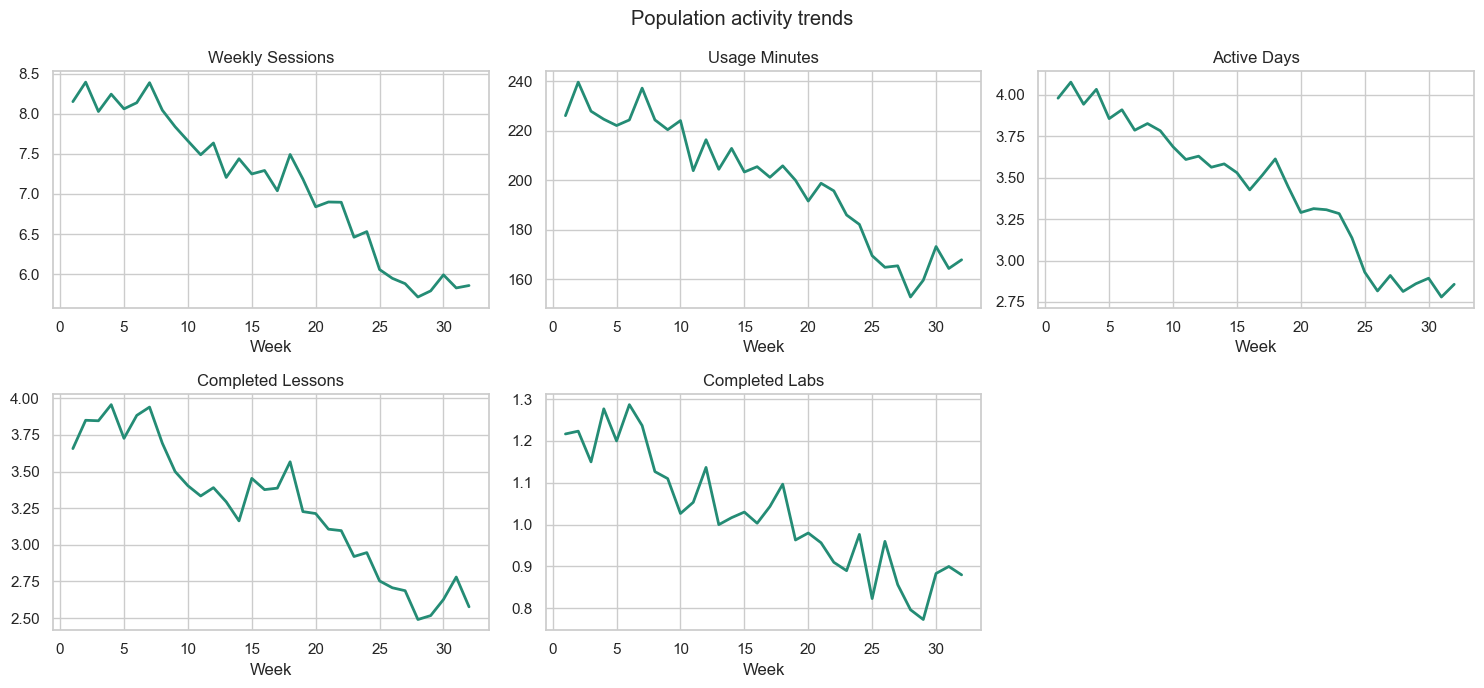

In [3]:
weekly=history.groupby('week')[['weekly_sessions','usage_minutes','active_days','completed_lessons','completed_labs']].mean()
fig,axes=plt.subplots(2,3,figsize=(15,7))
for ax,col in zip(axes.flat,weekly.columns):
    ax.plot(weekly.index,weekly[col],color='#248c75',lw=2); ax.set_title(col.replace('_',' ').title()); ax.set_xlabel('Week')
axes.flat[-1].axis('off'); fig.suptitle('Population activity trends'); plt.tight_layout()

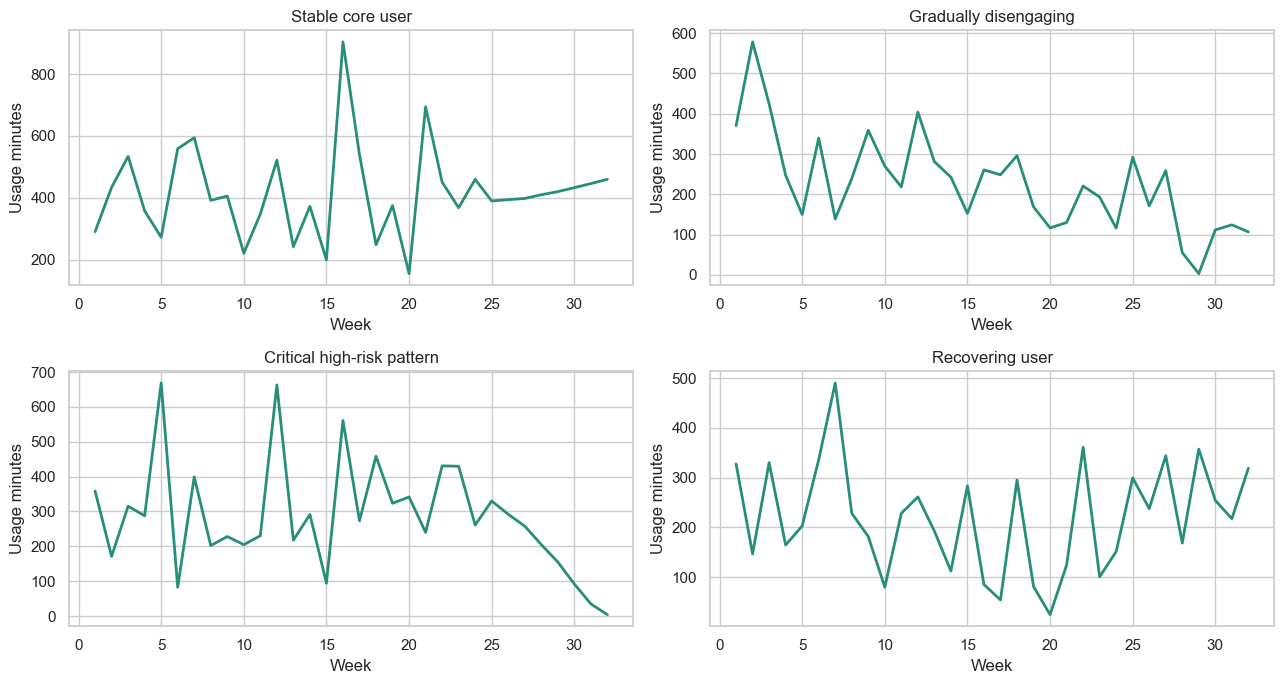

In [4]:
fig,axes=plt.subplots(2,2,figsize=(13,7))
names={'C001':'Stable core user','C002':'Gradually disengaging','C003':'Critical high-risk pattern','C004':'Recovering user'}
for ax,cid in zip(axes.flat,names):
    g=history[history.customer_id==cid]; ax.plot(g.week,g.usage_minutes,color='#278e79',lw=2); ax.set(title=names[cid],xlabel='Week',ylabel='Usage minutes')
plt.tight_layout()

## C — Behavioral feature engineering

Customer features use recent and prior four-week windows, an eight-week volatility window, and lag/rolling features at the end of the observed series. No post-prediction data enters X.

In [5]:
from scripts.export_models import engineer_features,FEATURES
features=engineer_features(history)
display(features[['customer_id','recent_sessions','sessions_trend','recent_usage_minutes','usage_trend','days_since_last_activity','activity_lag_1','rolling_mean_4','cancelled']].head())
assert features.customer_id.nunique()==300 and set(FEATURES).issubset(features.columns)
assert 'cancelled' not in FEATURES, 'Target leakage detected'

,customer_id,recent_sessions,sessions_trend,recent_usage_minutes,usage_trend,days_since_last_activity,activity_lag_1,rolling_mean_4,cancelled
0,C001,16.00,1.75,439.750,41.750,1.00,17,16.00,0
1,C002,3.50,-3.25,86.625,-107.800,24.75,3,3.50,1
2,C003,2.25,-7.50,71.500,-199.750,28.75,0,2.25,1
3,C004,8.75,-0.50,286.875,24.575,26.50,9,8.75,0
4,C005,6.50,0.50,178.375,4.275,15.75,6,6.50,0


## D — Customer clustering and segmentation

The shared exporter standardizes behavior features, compares K-Means and DBSCAN, and uses PCA only for the two-dimensional similarity map. Segment names are assigned after inspecting activity summaries. The phrase “at risk” is reserved for the supervised classifier.

## E — Churn classification

Logistic Regression is the baseline; Random Forest is the nonlinear comparison. The train/test split is by customer, so a learner cannot appear in both sets. Models are evaluated on the held-out customers before the chosen model is refit on the full dataset for the application.

C:\Users\LAPSHOP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


Exported pipeline for 300 customers. Churn rate=38.0%, selected classifier=Logistic Regression, forecast=exp_smoothing.


,0
selected_model,K-Means
kmeans_clusters,5
kmeans_silhouette,0.17499
dbscan_clusters,2
dbscan_noise_points,233
dbscan_silhouette,0.193308
selection_reason,K-Means gives every customer a stable segment ...


,customers,recent_sessions,usage_trend,recent_usage,inactivity
cluster,,,,,
0,64,2.76,-36.42,77.88,26.02
1,53,12.56,66.99,357.89,11.88
2,57,7.93,61.52,228.45,17.85
3,79,1.13,-4.98,35.74,29.70
4,47,8.00,-72.34,215.04,16.23


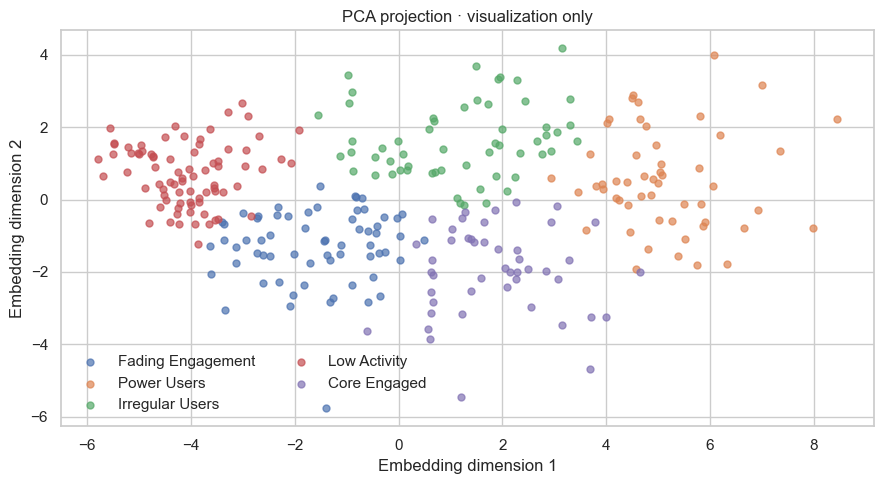

In [6]:
from scripts.export_models import train_export
train_export()  # same exporter used by FastAPI
metrics=json.loads((ROOT/'models/metrics.json').read_text(encoding='utf-8'))
bundle=joblib.load(ROOT/'models/pipeline.joblib')
X=features[bundle['features']].replace([np.inf,-np.inf],0).fillna(0)
coords=bundle['embedding'].transform(bundle['scaler'].transform(X))
clusters=features.copy(); clusters['cluster']=bundle['kmeans'].predict(bundle['scaler'].transform(X))
display(pd.DataFrame(metrics['clustering'],index=[0]).T)
display(clusters.groupby('cluster').agg(customers=('customer_id','count'),recent_sessions=('recent_sessions','mean'),usage_trend=('usage_trend','mean'),recent_usage=('recent_usage_minutes','mean'),inactivity=('days_since_last_activity','mean')).round(2))
fig,ax=plt.subplots(figsize=(9,5))
for k in sorted(clusters.cluster.unique()):
    mask=clusters.cluster.to_numpy()==k; ax.scatter(coords[mask,0],coords[mask,1],s=25,alpha=.7,label=bundle['cluster_names'][int(k)])
ax.set(title='PCA projection · visualization only',xlabel='Embedding dimension 1',ylabel='Embedding dimension 2'); ax.legend(frameon=False,ncol=2); plt.tight_layout()

In [7]:
report=metrics['classification']
display(pd.DataFrame(report['models']).T.round(3))
display(Markdown(f"**Selected:** {report['selected_model']} · customer-level holdout of {report['holdout_size']} learners. Recall is emphasized because the demo aims to identify learners before cancellation."))
prob=bundle['classifier'].predict_proba(X)[:,1]
display(pd.DataFrame({'customer_id':features.customer_id,'churn_probability':prob,'risk_tier':pd.cut(prob,[-.001,.30,.60,.80,1.001],labels=['STABLE','WATCHLIST','AT RISK','CRITICAL'])}).head())

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.787,0.688,0.786,0.733,0.88
Random Forest,0.773,0.739,0.607,0.667,0.83


**Selected:** Logistic Regression · customer-level holdout of 75 learners. Recall is emphasized because the demo aims to identify learners before cancellation.

,customer_id,churn_probability,risk_tier
0,C001,0.005898,STABLE
1,C002,0.984338,CRITICAL
2,C003,0.999753,CRITICAL
3,C004,0.176547,STABLE
4,C005,0.259842,STABLE


## F — Four-week time-series forecasting

Naive last-value and damped-trend exponential smoothing forecasts are compared by walk-forward validation at weeks 20, 24, and 28. Each fold predicts the following four weeks from earlier observations only. MAE selects the method used by the app; RMSE and MAPE are also reported. MAPE omits near-zero actuals.

,mae,rmse,mape
naive,103.73,143.80,133.93
exp_smoothing,88.82,121.56,138.18


Selected forecasting method: exp_smoothing


,week,usage_minutes,lower,upper
0,25,330.0,NaN,NaN
1,26,292.0,NaN,NaN
2,27,258.0,NaN,NaN
3,28,205.0,NaN,NaN
4,29,155.0,NaN,NaN
5,30,92.0,NaN,NaN
6,31,35.0,NaN,NaN
7,32,4.0,NaN,NaN
8,33,0.0,0.0,207.439385
9,34,0.0,0.0,207.439385


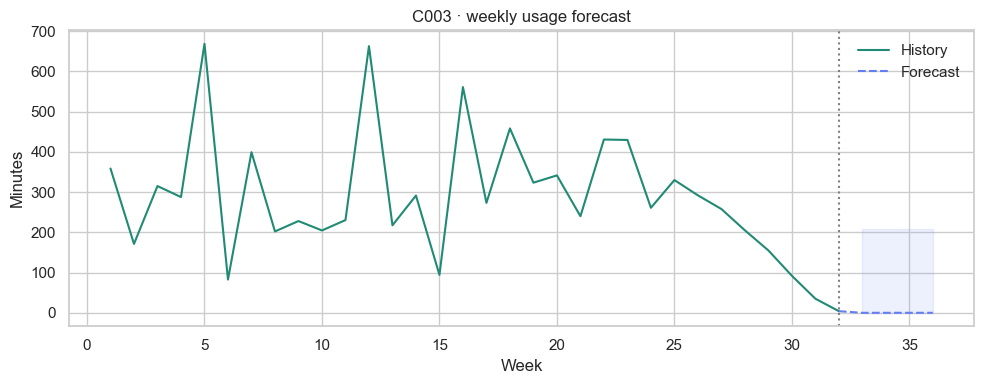

In [8]:
display(pd.DataFrame(metrics['forecasting']['metrics']).T.round(2))
print('Selected forecasting method:',metrics['forecasting']['selected_model'])
from backend.forecasting import forecast as customer_forecast
fc=customer_forecast('C003'); display(pd.DataFrame(fc['history'][-8:]+fc['forecast']))
fig,ax=plt.subplots(figsize=(10,4)); hx=[x['week'] for x in fc['history']]; hy=[x['usage_minutes'] for x in fc['history']]
fx=[hx[-1]]+[x['week'] for x in fc['forecast']]; fy=[hy[-1]]+[x['usage_minutes'] for x in fc['forecast']]
ax.plot(hx,hy,color='#218a74',label='History'); ax.plot(fx,fy,'--',color='#647ef2',label='Forecast')
ax.fill_between([x['week'] for x in fc['forecast']],[x['lower'] for x in fc['forecast']],[x['upper'] for x in fc['forecast']],color='#8498f5',alpha=.14)
ax.axvline(hx[-1],color='gray',ls=':'); ax.set(title='C003 · weekly usage forecast',xlabel='Week',ylabel='Minutes'); ax.legend(frameon=False); plt.tight_layout()

## G — SHAP explanation

The service calculates customer-level SHAP values from the exported classifier. Positive contributions increase the fitted model score; negative contributions reduce it. SHAP is an explanation of model behavior, not a causal estimate.

C:\Users\LAPSHOP\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,feature,label,value
0,usage_trend,Usage trend,6.460401
1,active_days_trend,Active days trend,1.400611
2,activity_lag_1,Activity Lag 1,1.201659
3,sessions_trend,Declining sessions,-0.835311
4,days_since_last_activity,Recent inactivity,0.464190
5,engagement_volatility,Engagement volatility,0.395728
6,rolling_mean_4,Rolling Mean 4,-0.368605
7,recent_sessions,Recent sessions,-0.368605


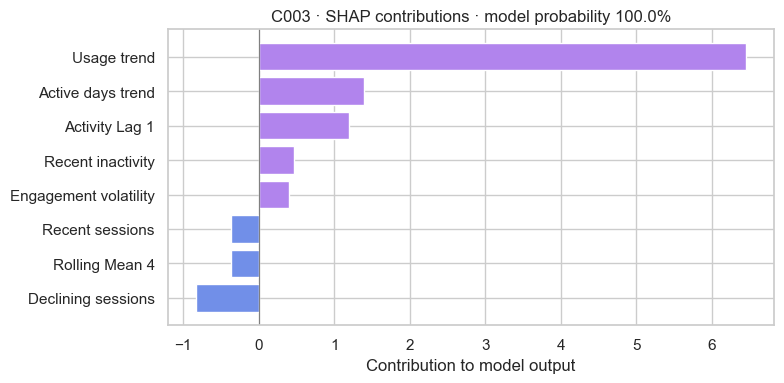

In [9]:
from backend.explainability import explanation
e=explanation('C003'); display(pd.DataFrame(e['values']))
chart=pd.DataFrame(e['values']).sort_values('value')
plt.figure(figsize=(8,4)); plt.barh(chart.label,chart.value,color=['#718fe8' if x<0 else '#b184ed' for x in chart.value]); plt.axvline(0,color='gray',lw=.8)
plt.title(f"C003 · SHAP contributions · model probability {e['probability']:.1%}"); plt.xlabel('Contribution to model output'); plt.tight_layout()

## H — Customer preferences and grounded AI agent

Preferences come from the separate profile table. The backend supplies churn probability/tier, forecast values, SHAP evidence, preferences, and an eligibility-filtered action list. GPT-OSS may select only an eligible action. If Ollama is unavailable, or output fails validation, the application uses deterministic recommendation mode.

| Evidence source | Allowed role |
|---|---|
| Churn classifier | Probability and risk tier |
| Forecasting model | Future weekly usage |
| SHAP | Model feature contributions |
| Customer profile | Recorded preferences |
| GPT-OSS | Eligible action choice and personalized wording |

Action execution is simulated in memory; it never sends a message.

In [10]:
from backend.customer_service import profile
from backend.decision_policy import eligible_actions,deterministic_recommendation
p=profile('C003'); display(pd.Series(p['preferences'],name='Recorded profile'))
print('Model risk:',p['risk'],f"({p['churn_probability']:.1%})")
print('Eligible actions:',eligible_actions('C003')); display(pd.Series(deterministic_recommendation('C003')))

age_group                           45+
favorite_topic                      NLP
preferred_content_type         Projects
preferred_feature              Projects
preferred_study_time            Morning
historical_engagement_level        High
Name: Recorded profile, dtype: object

Model risk: CRITICAL (100.0%)
Eligible actions: ['PREMIUM_FEATURE_TRIAL', 'ONE_FREE_MONTH', 'RE_ENGAGEMENT_MESSAGE', 'PERSONALIZED_CONTENT_RECOMMENDATION', 'STUDY_PLAN_RECOMMENDATION', 'LEARNING_PATH_RECOMMENDATION']


action                                          PREMIUM_FEATURE_TRIAL
action_label                              7-day premium feature trial
reason              The model assigns 100% churn probability (CRIT...
message             Hi! We picked out NLP projects that fit your i...
provider                                                deterministic
fallback                                                         True
eligible_actions    [PREMIUM_FEATURE_TRIAL, ONE_FREE_MONTH, RE_ENG...
dtype: object

## I — Exported artifacts and leakage checks

`models/pipeline.joblib` is the exact artifact loaded by FastAPI: selected classifier, feature schema, scaler, K-Means/PCA models, segment names, SHAP background, and forecasting method. `models/metrics.json` contains the evaluations. CSVs and models reproduce with seed 42.

The prediction label is separate from feature construction; profile preferences and age group are excluded from classifier inputs. No training occurs inside API routes.